In [1]:
%load_ext autotime

import scarf

scarf.__version__

'1.0.0'

time: 1.89 s (started: 2026-07-17 01:30:42 +02:00)


In [2]:
scarf.fetch_dataset(
    dataset_name="kang_15K_pbmc_rnaseq", save_path="scarf_datasets", as_zarr=True
)

scarf.fetch_dataset(
    dataset_name="kang_14K_ifnb-pbmc_rnaseq", save_path="scarf_datasets", as_zarr=True
)

time: 25.5 s (started: 2026-07-17 01:30:44 +02:00)


In [3]:
ds_ctrl = scarf.DataStore("scarf_datasets/kang_15K_pbmc_rnaseq/data.zarr/", nthreads=4)

ds_ctrl

DataStore has 8487 (14619) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'cluster_labels', 'RNA_percentMito', 
            'RNA_percentRibo', 'RNA_nFeatures', 'RNA_nCounts', 'RNA_leiden_cluster', 'RNA_UMAP1', 
            'RNA_UMAP2'
   RNA assay has 11352 (35635) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'I__hvgs', 
            'dropOuts'

time: 288 ms (started: 2026-07-17 01:31:08 +02:00)


In [4]:
ds_stim = scarf.DataStore(
    "scarf_datasets/kang_14K_ifnb-pbmc_rnaseq/data.zarr", nthreads=4
)

ds_stim

DataStore has 10111 (14446) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'cluster_labels', 
            'RNA_percentRibo', 'RNA_nFeatures', 'RNA_nCounts', 'RNA_leiden_cluster', 'RNA_UMAP1', 
            'RNA_UMAP2'
   RNA assay has 11051 (35635) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'I__hvgs', 
            'dropOuts'

time: 353 ms (started: 2026-07-17 01:31:08 +02:00)


In [5]:
scarf.AssayMerge(
    zarr_path="scarf_datasets/kang_merged_pbmc_rnaseq.zarr",
    assays=[ds_ctrl.RNA, ds_stim.RNA],
    names=["ctrl", "stim"],
    merge_assay_name="RNA",
    overwrite=True,
).dump()

Writing countsT shape=(35635, 29065) chunks=(35635, 15065)



time: 1min 5s (started: 2026-07-17 01:31:08 +02:00)


In [6]:
ds = scarf.DataStore("scarf_datasets/kang_merged_pbmc_rnaseq.zarr", nthreads=4)

Minimum cell count (562) is lower than size factor multiplier (1000)



time: 26.8 s (started: 2026-07-17 01:32:10 +02:00)


In [7]:
ds

DataStore has 29065 (29065) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'orig_RNA_UMAP1', 'RNA_percentMito', 
            'orig_RNA_percentRibo', 'orig_RNA_percentMito', 'orig_RNA_UMAP2', 'orig_cluster_labels', 'orig_RNA_nCounts', 
            'orig_RNA_nFeatures', 'RNA_percentRibo', 'RNA_nFeatures', 'RNA_nCounts', 'orig_RNA_leiden_cluster', 
          
   RNA assay has 12450 (35635) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

time: 84.2 ms (started: 2026-07-17 01:32:35 +02:00)


In [8]:
ds.cells.head()

,I,ids,names,RNA_percentMito,orig_RNA_nCounts,orig_RNA_UMAP1,orig_RNA_percentMito,orig_RNA_percentRibo,orig_RNA_UMAP2,orig_cluster_labels,orig_RNA_nFeatures,RNA_nFeatures,orig_RNA_leiden_cluster,RNA_percentRibo,RNA_nCounts
0,True,ctrl__TGTTAAGACACTGA-1,TGTTAAGACACTGA-1,0.000000,574.0,NaN,0.000000,20.034843,NaN,nan,304.0,304.0,-1,20.034843,574.0
1,True,ctrl__TCACCCGAGCTATG-1,TCACCCGAGCTATG-1,0.000000,1682.0,NaN,0.000000,0.059453,NaN,nan,62.0,62.0,-1,0.059453,1682.0
2,True,ctrl__TCACCCGAACCACA-1,TCACCCGAACCACA-1,0.171233,1168.0,-1.768571,0.171233,31.763699,-5.990341,CD4 Memory T,434.0,434.0,1,31.763699,1168.0
3,True,ctrl__TGTAGTCTACCAGT-1,TGTAGTCTACCAGT-1,0.185357,2158.0,-3.052445,0.185357,32.483781,-12.830768,CD8 T,837.0,837.0,7,32.483781,2158.0
4,True,ctrl__TATCAGCTAGTAGA-1,TATCAGCTAGTAGA-1,0.143369,1395.0,-12.654625,0.143369,34.695341,-5.425503,B,592.0,592.0,5,34.695341,1395.0


time: 255 ms (started: 2026-07-17 01:32:35 +02:00)


In [9]:
ds.cells.insert(
    column_name="sample_id",
    values=[x.split("__")[0] for x in ds.cells.fetch_all("ids")],
    overwrite=True,
)

time: 51.1 ms (started: 2026-07-17 01:32:35 +02:00)


In [10]:
ctrl_labels = list(ds_ctrl.cells.fetch_all("cluster_labels"))
stim_labels = list(ds_stim.cells.fetch_all("cluster_labels"))

ds.cells.insert(
    column_name="imported_labels", values=ctrl_labels + stim_labels, overwrite=True
)

time: 72.5 ms (started: 2026-07-17 01:32:35 +02:00)


In [11]:
ctrl_valid_cells = list(ds_ctrl.cells.fetch_all("I"))
stim_valid_cells = list(ds_stim.cells.fetch_all("I"))

ds.cells.update_key(values=ctrl_valid_cells + stim_valid_cells, key="I")

time: 60.8 ms (started: 2026-07-17 01:32:35 +02:00)


In [12]:
ds.cells.to_pandas_dataframe(["sample_id"], key="I")["sample_id"].value_counts()

sample_id
ctrl    9441
stim    9157
Name: count, dtype: int64

time: 83.3 ms (started: 2026-07-17 01:32:35 +02:00)


Calculating summary statistics



(RNA) feature stats block 1/2: read 2.4s (r2) compute 0.6s rss 1616 MiB



(RNA) feature stats block 2/2: read 2.0s (ram) compute 0.6s rss 1175 MiB



Calculating HVGs



2000 genes marked as HVGs



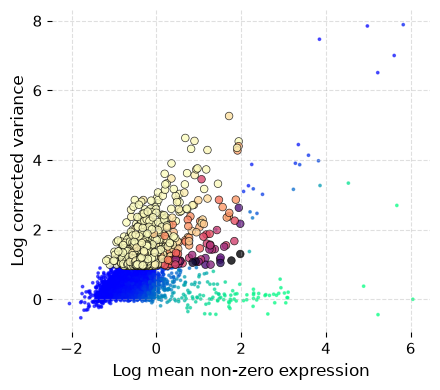

time: 7.68 s (started: 2026-07-17 01:32:36 +02:00)


In [13]:
ds.mark_hvgs(min_cells=10, top_n=2000, min_mean=-3, max_mean=2, max_var=6)

In [14]:
ds.make_graph(feat_key="hvgs", k=21, dims=25, n_centroids=100)

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 6.9s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.4s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

ANN recall: 99.95%



make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 43.2s (7/7 steps, 43.2s in logged steps)



time: 43.2 s (started: 2026-07-17 01:32:43 +02:00)


In [15]:
ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True)

Training UMAP:   0%|                                                                                          …

time: 11.1 s (started: 2026-07-17 01:33:25 +02:00)


/home/parashar/scarf/scarf/metadata.py:416: RuntimeWarning: overflow encountered in cast
  a = np.empty(self.N).astype(values.dtype)


In [16]:
ds.cells.head()

,I,ids,names,RNA_percentMito,orig_RNA_nCounts,orig_RNA_UMAP1,orig_RNA_UMAP2,orig_RNA_percentMito,orig_RNA_percentRibo,orig_cluster_labels,RNA_percentRibo,RNA_nFeatures,orig_RNA_nFeatures,RNA_nCounts,imported_labels,orig_RNA_leiden_cluster,sample_id,RNA_UMAP2,RNA_UMAP1
0,True,ctrl__TGTTAAGACACTGA-1,TGTTAAGACACTGA-1,0.000000,574.0,NaN,NaN,0.000000,20.034843,nan,20.034843,304.0,304.0,574.0,CD4 naive T,-1,ctrl,-14.790999,-15.586755
1,True,ctrl__TCACCCGAGCTATG-1,TCACCCGAGCTATG-1,0.000000,1682.0,NaN,NaN,0.000000,0.059453,nan,0.059453,62.0,62.0,1682.0,CD 14 Mono,-1,ctrl,-7.480762,36.264912
2,True,ctrl__TCACCCGAACCACA-1,TCACCCGAACCACA-1,0.171233,1168.0,-1.768571,-5.990341,0.171233,31.763699,CD4 Memory T,31.763699,434.0,434.0,1168.0,CD 14 Mono,1,ctrl,-26.104013,4.518086
3,True,ctrl__TGTAGTCTACCAGT-1,TGTAGTCTACCAGT-1,0.185357,2158.0,-3.052445,-12.830768,0.185357,32.483781,CD8 T,32.483781,837.0,837.0,2158.0,CD 14 Mono,7,ctrl,-20.980219,-4.914535
4,False,ctrl__TATCAGCTAGTAGA-1,TATCAGCTAGTAGA-1,0.143369,1395.0,-12.654625,-5.425503,0.143369,34.695341,B,34.695341,592.0,592.0,1395.0,nan,5,ctrl,NaN,NaN


time: 436 ms (started: 2026-07-17 01:33:34 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


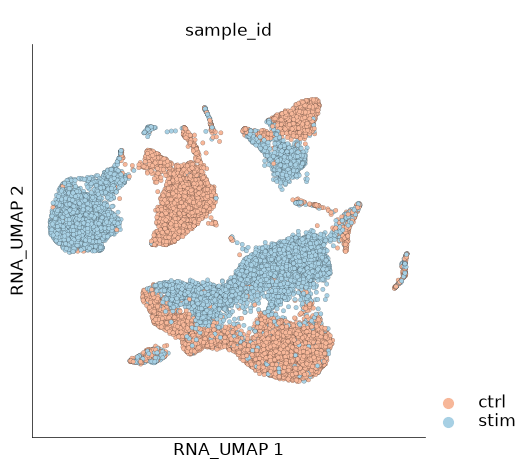

time: 686 ms (started: 2026-07-17 01:33:35 +02:00)


In [17]:
ds.plot_layout(
    layout_key="RNA_UMAP", color_by="sample_id", cmap="RdBu", legend_ondata=False
)

/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


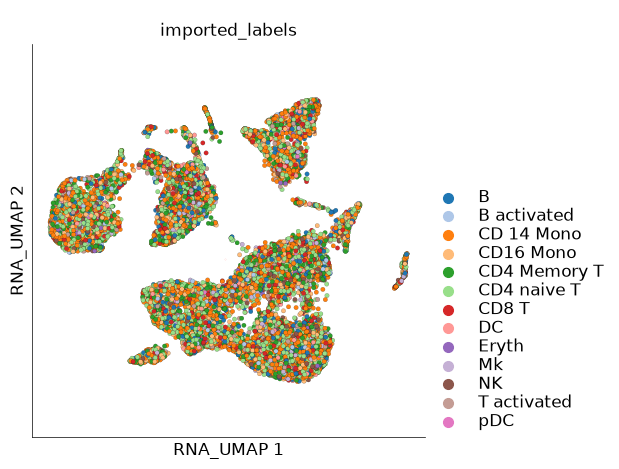

time: 724 ms (started: 2026-07-17 01:33:35 +02:00)


In [18]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="imported_labels", legend_ondata=False)

In [19]:
ds.cells.insert(
    column_name="is_ctrl",
    values=(ds.cells.fetch_all("sample_id") == "ctrl"),
    overwrite=True,
)

time: 47.1 ms (started: 2026-07-17 01:33:36 +02:00)


In [20]:
ds.make_graph(feat_key="hvgs", k=21, dims=25, n_centroids=100, pca_cell_key="is_ctrl")

make_graph step 1/7: normalize expression matrix (reusing cached)



Using existing normalized data with cell key I and feat key I__hvgs



make_graph step 1/7: normalize expression matrix finished in 0.1s (reusing cached)



make_graph step 2/7: normalization statistics (reusing cached)



make_graph step 2/7: normalization statistics finished in 0.0s (reusing cached)



...

ANN recall: 99.82%



make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 13.9s (7/7 steps, 13.8s in logged steps)



time: 14 s (started: 2026-07-17 01:33:36 +02:00)


In [21]:
ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True, label="pUMAP")

Training UMAP:   0%|                                                                                          …

time: 9.69 s (started: 2026-07-17 01:33:50 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


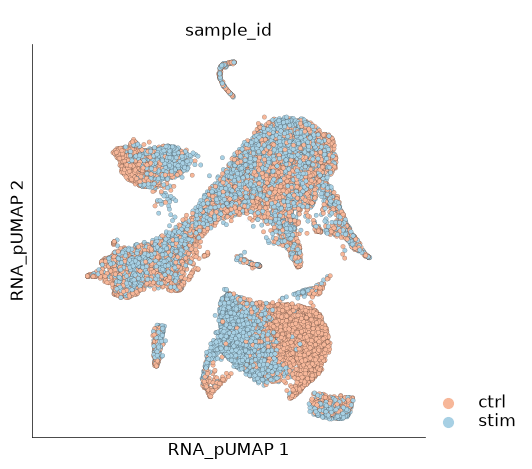

time: 1.01 s (started: 2026-07-17 01:33:58 +02:00)


In [22]:
ds.plot_layout(
    layout_key="RNA_pUMAP", color_by="sample_id", cmap="RdBu", legend_ondata=False
)

/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


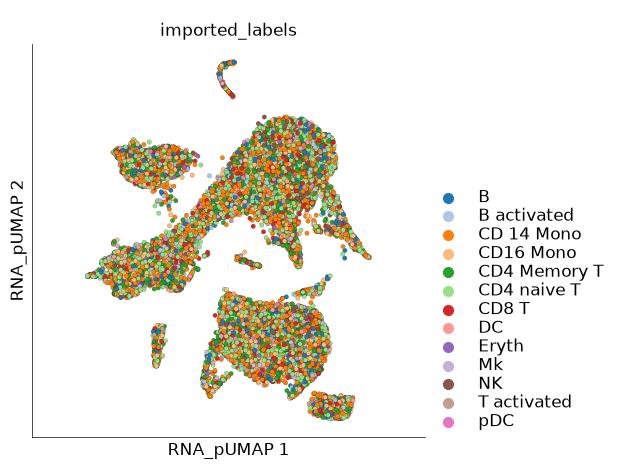

time: 1.12 s (started: 2026-07-17 01:33:59 +02:00)


In [23]:
ds.plot_layout(layout_key="RNA_pUMAP", color_by="imported_labels", legend_ondata=False)

In [24]:
ds.make_graph(
    feat_key="hvgs",
    k=21,
    dims=25,
    n_centroids=100,
    harmonize=True,
    batch_columns=["sample_id"],
)

ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True, label="hUMAP")

ds.run_leiden_clustering(resolution=1.0)

make_graph step 1/7: normalize expression matrix (reusing cached)



Using existing normalized data with cell key I and feat key I__hvgs



make_graph step 1/7: normalize expression matrix finished in 0.2s (reusing cached)



make_graph step 2/7: normalization statistics (reusing cached)



make_graph step 2/7: normalization statistics finished in 0.0s (reusing cached)



...

make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 31.4s (7/7 steps, 30.7s in logged steps)



Training UMAP:   0%|                                                                                          …

time: 44.3 s (started: 2026-07-17 01:34:00 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


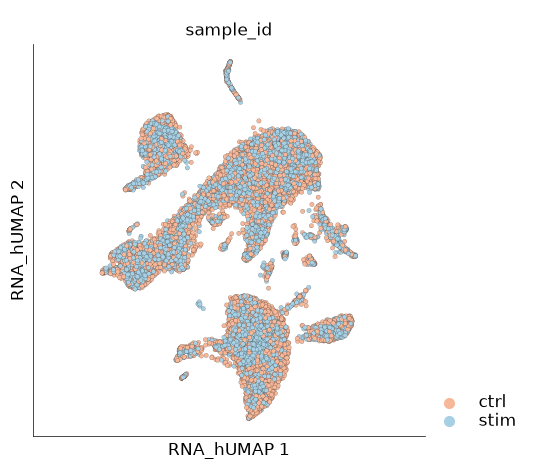

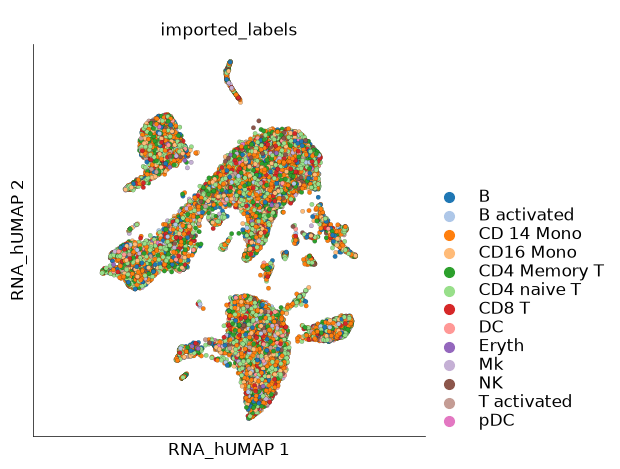

time: 1.46 s (started: 2026-07-17 01:34:43 +02:00)


In [25]:
ds.plot_layout(
    layout_key="RNA_hUMAP", color_by="sample_id", cmap="RdBu", legend_ondata=False
)

ds.plot_layout(layout_key="RNA_hUMAP", color_by="imported_labels", legend_ondata=False)

In [26]:
ds.metric_lisi(
    label_colnames=["sample_id", "imported_labels"],
    save_result=True,
)

Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__is_ctrl/ann__l2__63__63__48__4466__harmony_66edd4379bf9493b/knn__21



Perplexity 30 requires at least 90 neighbors, but the graph has 21. Using perplexity 7.



Computing LISI for sample_id



Computing LISI for imported_labels



[('sample_id',
  array([1.82219041, 1.47875387, 1.72050892, ..., 1.9986971 , 1.29487023,
         1.04752205], shape=(18598,))),
 ('imported_labels',
  array([2.72212043, 3.65864004, 2.12411135, ..., 3.33422435, 2.20356394,
         4.4492713 ], shape=(18598,)))]

time: 428 ms (started: 2026-07-17 01:34:44 +02:00)


In [27]:
ds.metric_batch_mixing(label_colname="sample_id")

Using the knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__is_ctrl/ann__l2__63__63__48__4466__harmony_66edd4379bf9493b/knn__21



Perplexity 30 requires at least 90 neighbors, but the graph has 21. Using perplexity 7.



Computing LISI for sample_id



0.4225426493670202

time: 338 ms (started: 2026-07-17 01:34:45 +02:00)


In [28]:
ds.metric_silhouette(res_label="leiden_cluster")

Using the latest knn graph at location: RNA/normed__I__hvgs/reduction__pca__25__is_ctrl/ann__l2__63__63__48__4466__harmony_66edd4379bf9493b/knn__21 for assay: RNA



Loaded existing ANN stream from RNA/normed__I__hvgs/reduction__pca__25__is_ctrl/ann__l2__63__63__48__4466__harmony_66edd4379bf9493b



array([ 0.25132455,  0.23440473,  0.11844284,  0.4121762 ,  0.22050369,
        0.06412872,  0.21549733,  0.29761931,  0.08568681,  0.05195516,
        0.10802172,  0.48158152,  0.50115504,  0.32112733,  0.31548232,
       -0.06508764,  0.09314139,  0.16435866])

time: 656 ms (started: 2026-07-17 01:34:45 +02:00)


In [29]:
ds.metric_label_concordance(
    label_columns=["sample_id", "imported_labels"], metric="ari"
)

-3.705291026995729e-06

time: 75.5 ms (started: 2026-07-17 01:34:46 +02:00)
